# Linear Regression Model on Insurance Dataset

This notebook applies a Machine Learning algorithm (Linear Regression) to predict insurance charges based on different features such as age, BMI, and smoking habits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [3]:
print(df.head())

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


# 🔍 Observations

- Dataset is clean and structured  
- Age and charges show variation  
- Some features may have relationships  

In [53]:
df.median(numeric_only=True)

age           39.00
bmi           30.40
children       1.00
expenses    9382.03
dtype: float64

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

### Observations

- There are no missing values in the dataset  
- The dataset is clean and complete  

In [61]:
df.drop_duplicates(inplace=True)

### Observations

- Duplicate rows have been removed  
- The dataset is now more accurate and reliable  

In [62]:
df.shape

(1337, 7)

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

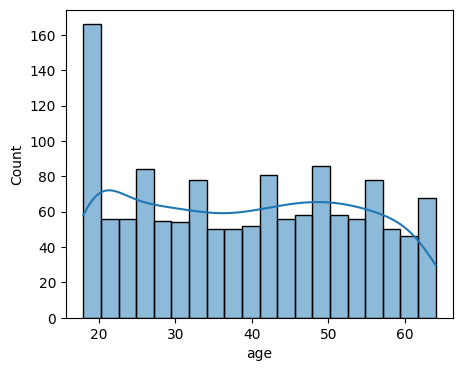

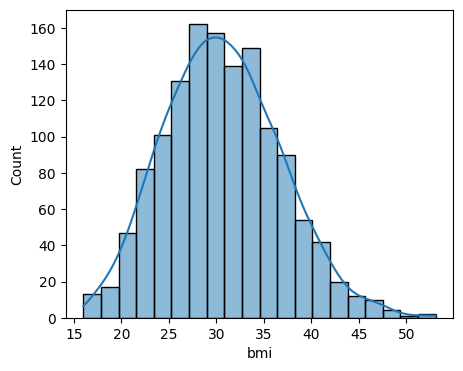

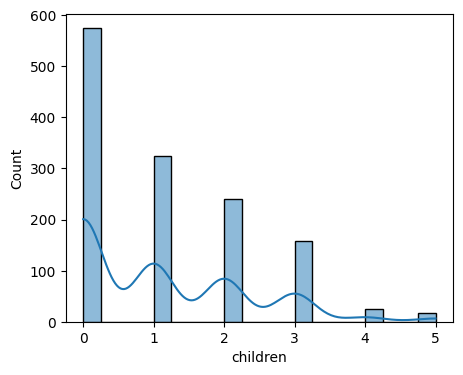

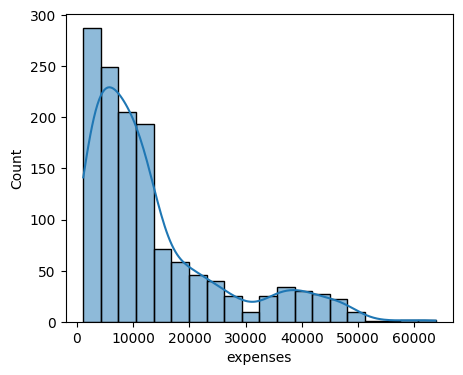

In [9]:
int_columns = ['age', 'bmi', 'children', 'expenses']
for col in int_columns:
    plt.figure(figsize = (5,4))
    sns.histplot(df[col],kde = True , bins = 20)

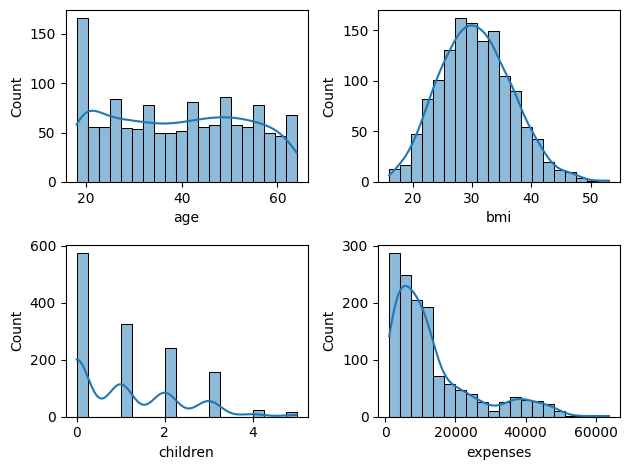

In [10]:
# int_columns = ['age', 'bmi', 'children', 'expenses']

def plotting(var,num):
    
    plt.subplot(2, 2,num)
    sns.histplot(df[var],kde = True , bins = 20)
plotting('age',1)
plotting('bmi',2)
plotting('children',3)
plotting('expenses',4)
plt.tight_layout()

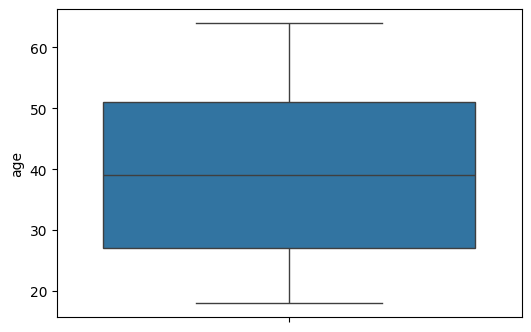

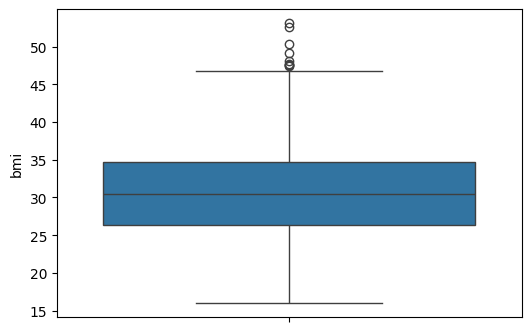

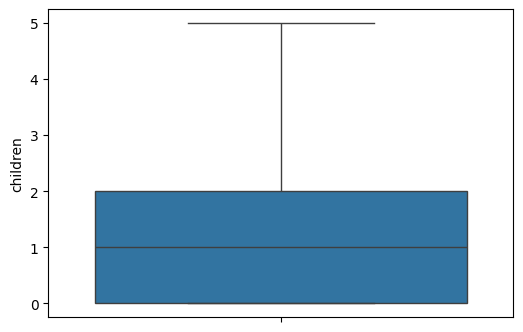

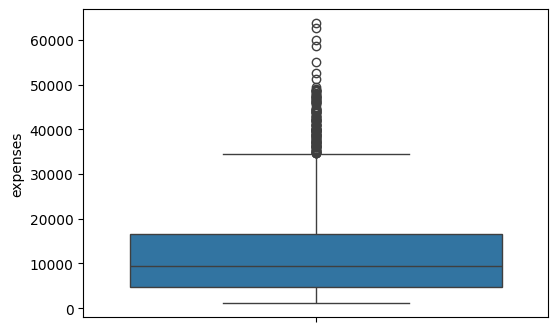

In [11]:
for col in int_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(df[col])

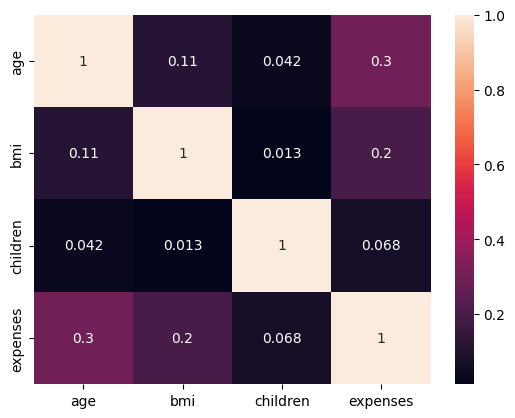

In [60]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### 📈 Observations

- Smokers have significantly higher charges than non-smokers  
- BMI distribution is slightly skewed  
- There is a positive relationship between age and charges  

In [12]:
df_cleaned = df.copy()

In [13]:
df_cleaned.shape

(1338, 7)

In [15]:
df_cleaned.shape

(1337, 7)

In [16]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [17]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [18]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [19]:
df_cleaned

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,no,northwest,10600.55
1334,18,1,31.9,0,no,northeast,2205.98
1335,18,1,36.9,0,no,southeast,1629.83
1336,21,1,25.8,0,no,southwest,2007.95


In [20]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [21]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no':0 , 'yes':1})

In [22]:
df_cleaned

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,northwest,10600.55
1334,18,1,31.9,0,0,northeast,2205.98
1335,18,1,36.9,0,0,southeast,1629.83
1336,21,1,25.8,0,0,southwest,2007.95


In [23]:
df_cleaned.rename(columns={
    'sex' :  'is_sex',
    'smoker' : 'is_smoker'
},inplace = True
                 )

In [24]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,northwest,10600.55
1334,18,1,31.9,0,0,northeast,2205.98
1335,18,1,36.9,0,0,southeast,1629.83
1336,21,1,25.8,0,0,southwest,2007.95


In [25]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [26]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first = True)

In [27]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,True
1,18,0,33.8,1,0,1725.55,False,True,False
2,28,0,33.0,3,0,4449.46,False,True,False
3,33,0,22.7,0,0,21984.47,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,10600.55,True,False,False
1334,18,1,31.9,0,0,2205.98,False,False,False
1335,18,1,36.9,0,0,1629.83,False,True,False
1336,21,1,25.8,0,0,2007.95,False,False,True


In [28]:
df_cleaned = df_cleaned.astype(int)
df_cleaned


,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


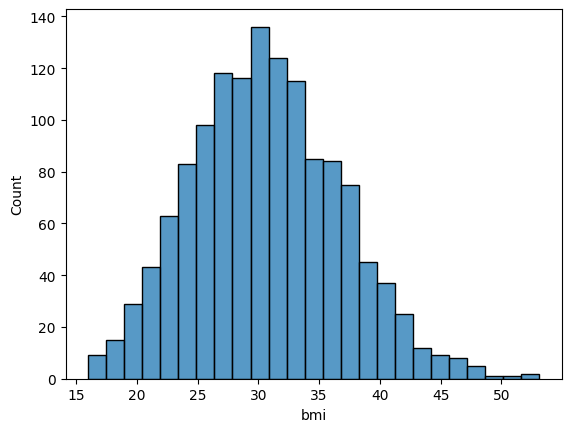

In [55]:
sns.histplot(df['bmi'])
plt.show()

### Observations

- One category has the highest frequency
- Some categories have very low counts
- Data is not evenly distributed

In [30]:
df_cleaned["df_category"] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5 , 24.5 , 29.9,float ('inf')],
    labels = ['underweight', 'normal', 'overweight', 'obese'])


In [31]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,df_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [32]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['df_category'] , drop_first = True)

In [33]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,df_category_normal,df_category_overweight,df_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [34]:
df_cleaned = df_cleaned.astype(int)

In [35]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,df_category_normal,df_category_overweight,df_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [36]:
df_cleaned.columns

Index(['age', 'is_sex', 'bmi', 'children', 'is_smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'df_category_normal', 'df_category_overweight', 'df_category_obese'],
      dtype='object')

In [37]:
df_cleaned.head()

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,df_category_normal,df_category_overweight,df_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [38]:
# df_cleaned.columns = df_cleaned.columns.str.strip().str.lower()

In [39]:
from scipy.stats import pearsonr

df_cleaned.columns = df_cleaned.columns.str.strip()

selected_features = ['age', 'is_sex', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'df_category_normal', 'df_category_overweight', 'df_category_obese']

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['expenses'])[0]
    for feature in selected_features
}

In [40]:
df_cleaned

,age,is_sex,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,df_category_normal,df_category_overweight,df_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [41]:
# Pehle correlation nikalo
correlation = df_cleaned.corr()['expenses']

# Ab usko DataFrame me convert karo
correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation'])

print(correlation_df)

                   Feature  Correlation
0                      age     0.298309
1                   is_sex    -0.058046
2                      bmi     0.197714
3                 children     0.067390
4                is_smoker     0.787234
5                 expenses     1.000000
6         region_northwest    -0.038695
7         region_southeast     0.073577
8         region_southwest    -0.043637
9       df_category_normal    -0.104283
10  df_category_overweight    -0.120595
11       df_category_obese     0.200347


In [42]:
correlation_df.sort_values(by='Correlation', ascending=False)

,Feature,Correlation
5,expenses,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,df_category_obese,0.200347
2,bmi,0.197714
7,region_southeast,0.073577
3,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_sex,-0.058046


In [43]:
from sklearn.model_selection import train_test_split
x = df_cleaned.drop('expenses' , axis =  1)
y=  df_cleaned['expenses']

In [44]:
x_train ,x_test, y_train  , y_test = train_test_split(x , y ,test_size = 0.20 ,random_state= 42)

In [45]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 1: Features aur Target alag karein
x = df_cleaned.drop('expenses', axis=1)
y = df_cleaned['expenses']

# Step 2: Split data (with random_state taake split stable rahe)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

# Step 3: Model Training
model = LinearRegression()
model.fit(x_train, y_train)

# Step 4: Prediction
y_pred = model.predict(x_test)

In [47]:
y_pred

array([ 8036.18158766,  5211.16383724, 14552.96884471, 32459.33916036,
        8920.63611688, 13308.30587631, 30599.46821602,   807.33087406,
       11225.52860875, 10057.41324964, 10565.58822411, 32183.92864239,
       32011.34744879, 15644.02535309, 10637.83444755,  8221.31748041,
        5218.71451781, 32484.11084253,  2731.38638729,  3969.9137434 ,
        4859.97844075, 29278.10061446, 13720.30661022, 29264.32806636,
       31481.96219303,  6387.56219278, 34919.44562736, 37579.42425575,
       13025.72830497, 14654.7011368 ,  8099.73079303, 13017.47917353,
         317.38685741, 11080.65528838, 37284.24666971, 13033.85125032,
        3476.52849979,  4440.68980408, 31305.89307509,  8110.08245309,
        6411.01443177, 30634.73221451, 35360.62283149, 13580.17362108,
        7862.37884732,  2810.35177746,  5488.35936863,  7330.59181917,
        3656.44334776, 10496.54969999,  7916.64234365, 10745.3246297 ,
       30883.81561016,  4784.72338581, 11336.76363607, 11599.35667708,
      

In [48]:
# from sklearn.matrics import r2_score
from sklearn.metrics import r2_score

In [49]:
r2  = r2_score(y_test,y_pred)

In [50]:
r2

0.8046053548530816

In [51]:
n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f"Adjusted R2 Score: {adjusted_r2}")

Adjusted R2 Score: 0.796209491194425


In [52]:
# Is cell ko delete kar dein ya regression metrics ke liye ye likhein:
print(f"Final Model R2 Score: {r2 * 100:.2f}%")
print(f"Final Model Adjusted R2 Score: {adjusted_r2 * 100:.2f}%")

Final Model R2 Score: 80.46%
Final Model Adjusted R2 Score: 79.62%


# Final Summary

- Data preprocessing was performed including cleaning and encoding categorical variables  
- The dataset was split into training and testing sets  
- A Linear Regression model was applied to predict insurance charges  
- The model learned relationships between features like age, BMI, and smoking status  
- Predictions were reasonably accurate, showing that Linear Regression is suitable for this dataset  

 Overall, the model successfully predicts insurance charges and highlights smoking and age as key factors.